# Phishing URL Dataset — EDA & Feature Engineering

This notebook performs **exploratory data analysis (EDA)** and **feature engineering** on raw URL data.

**Scope:**

- Aggregate raw URL files
- Explore URL structural differences between classes
- Derive engineered features motivated by EDA

**Out of scope:**

- Model training/evaluation


## SECTION 1 — Library Imports


In [96]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import tldextract
from urllib.parse import urlparse
from pathlib import Path

sns.set_theme(style="whitegrid", context="talk")

CLASS_LABELS = {0: "Legitimate", 1: "Phishing"}
CLASS_ORDER = ["Legitimate", "Phishing"]
CLASS_PALETTE = {"Legitimate": "#1f77b4", "Phishing": "#d62728"}

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 18,
    "axes.titleweight": "bold",
    "axes.labelsize": 14,
    "axes.labelweight": "semibold",
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "legend.title_fontsize": 12,
})

pd.set_option("display.max_colwidth", 140)

print("Libraries imported successfully.")

Libraries imported successfully.


## SECTION 2 — Load and Aggregate Dataset

This section loads all `.txt` files, auto-detects delimiters, handles unnamed columns, and standardizes labels to:

- `1` = phishing
- `0` = legitimate


### 2.1 Parsing helper functions


In [97]:
def detect_separator(sample_line: str):
    candidates = ["\t", ",", ";", "|"]
    counts = {sep: sample_line.count(sep) for sep in candidates}
    best_sep = max(counts, key=counts.get)
    return best_sep if counts[best_sep] > 0 else None


def parse_line_to_url_label(line: str, default_sep=None):
    line = line.strip()
    if not line:
        return None

    sep = default_sep if default_sep is not None else detect_separator(line)

    if sep is not None:
        parts = [p.strip() for p in line.split(sep)]
    else:
        parts = line.split()

    if len(parts) < 2:
        return None

    first, last = parts[0].lower(), parts[-1].lower()

    if first in {"0", "1", "phishing", "legitimate"}:
        raw_label = first
        url = sep.join(parts[1:]).strip() if sep else " ".join(parts[1:]).strip()
    elif last in {"0", "1", "phishing", "legitimate"}:
        raw_label = last
        url = sep.join(parts[:-1]).strip() if sep else " ".join(parts[:-1]).strip()
    else:
        return None

    label_map = {"1": 1, "0": 0, "phishing": 1, "legitimate": 0}
    label = label_map.get(raw_label)

    if label is None or not url:
        return None

    return {"url": url, "label": label}


def load_txt_dataset(file_path: Path):
    rows = []
    with open(file_path, "r", encoding="utf-8", errors="ignore") as f:
        lines = f.readlines()

    first_non_empty = next((ln.strip() for ln in lines if ln.strip()), "")
    sep = detect_separator(first_non_empty)

    for line in lines:
        parsed = parse_line_to_url_label(line, default_sep=sep)
        if parsed is not None:
            rows.append(parsed)

    return pd.DataFrame(rows, columns=["url", "label"])

### 2.2 Load and aggregate files


In [98]:
# Load all txt files and aggregate
base_path = Path("datasets")
all_txt_files = sorted(base_path.glob("*.txt"))

if not all_txt_files:
    raise FileNotFoundError("No .txt files found in ./datasets")

parts = []
for fp in all_txt_files:
    chunk = load_txt_dataset(fp)
    print(f"Loaded {fp.name}: {len(chunk):,} rows")
    parts.append(chunk)

raw_df = pd.concat(parts, ignore_index=True)
print(f"\nRaw aggregated rows: {len(raw_df):,}")

Loaded test.txt: 515,080 rows
Loaded train.txt: 3,641,986 rows
Loaded val.txt: 1,045,775 rows

Raw aggregated rows: 5,202,841


### 2.3 Data quality checks


In [99]:
# Basic data quality checks
null_counts = raw_df[["url", "label"]].isna().sum()
empty_url_count = int(raw_df["url"].astype(str).str.strip().eq("").sum())
duplicate_rows = int(raw_df.duplicated(subset=["url", "label"]).sum())
conflicting_label_urls = int(raw_df.groupby("url")["label"].nunique().gt(1).sum())

print("\n--- Data Quality Checks ---")
print(f"Null URLs: {int(null_counts['url']):,}")
print(f"Null labels: {int(null_counts['label']):,}")
print(f"Empty URL strings: {empty_url_count:,}")
print(f"Duplicate (url, label) rows: {duplicate_rows:,}")
print(f"URLs appearing with conflicting labels: {conflicting_label_urls:,}")


--- Data Quality Checks ---
Null URLs: 0
Null labels: 0
Empty URL strings: 0
Duplicate (url, label) rows: 19,775
URLs appearing with conflicting labels: 8


### 2.4 Clean and standardize dataset


In [100]:
# Clean and standardize dataset
df = raw_df[["url", "label"]].copy()
df["url"] = df["url"].astype(str).str.strip()
df["label"] = pd.to_numeric(df["label"], errors="coerce")

df = df.dropna(subset=["url", "label"])
df = df[df["url"] != ""]
df["label"] = df["label"].astype(int)
df = df[df["label"].isin({0, 1})]

# Remove exact duplicates
df = df.drop_duplicates(subset=["url", "label"])

# Remove URLs with conflicting labels (same URL appears as both classes)
conflict_urls = df.groupby("url")["label"].nunique()
conflict_urls = conflict_urls[conflict_urls > 1].index
if len(conflict_urls) > 0:
    df = df[~df["url"].isin(conflict_urls)]

# Final reset index
df = df.reset_index(drop=True)

phishing_count = int((df["label"] == 1).sum())
legitimate_count = int((df["label"] == 0).sum())

print("\n--- Cleaned Dataset Stats ---")
print(f"Total number of URLs: {len(df):,}")
print(f"Number of phishing URLs: {phishing_count:,}")
print(f"Number of legitimate URLs: {legitimate_count:,}")
print(f"Conflicting-label URLs removed: {len(conflict_urls):,}")

df.head()


--- Cleaned Dataset Stats ---
Total number of URLs: 5,183,050
Number of phishing URLs: 2,301,110
Number of legitimate URLs: 2,881,940
Conflicting-label URLs removed: 8


,url,label
0,https://blockchaoin.info/#/,1
1,https://www.insects.org/ced4/crush_freaks.html,0
2,https://www.elpasotimes.com/story/opinion/editorials/2015/11/17/editorial-terror-attack-brings-tough-choices/75960544/,0
3,http://direct-certs.bankofamerica.com.techdbaseurl46.cn/direct/certpickup.asp?session=52058170506675676020665110252458964995749207020054...,1
4,https://gotham-magazine.com/lalique-unveils-epis-ring,0


## SECTION 3 — Basic Dataset EDA

We review overall class balance and inspect random examples from each class.


### 3.1 Dataset overview


In [101]:
# Dataset overview
total_samples = len(df)
phishing_count = int((df["label"] == 1).sum())
legitimate_count = int((df["label"] == 0).sum())

print("Dataset Overview")
print(f"Total samples: {total_samples:,}")
print(f"Phishing count (1): {phishing_count:,}")
print(f"Legitimate count (0): {legitimate_count:,}")

Dataset Overview
Total samples: 5,183,050
Phishing count (1): 2,301,110
Legitimate count (0): 2,881,940


### 3.2 Class distribution chart


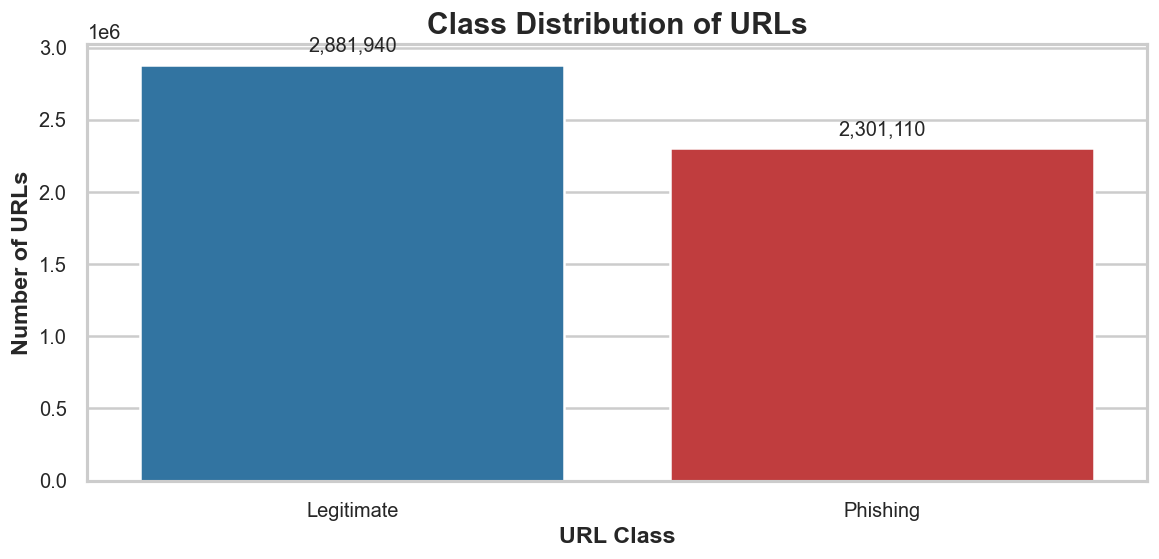

In [102]:
# Class distribution bar chart
class_counts = (
    df["label"]
    .map(CLASS_LABELS)
    .value_counts()
    .reindex(CLASS_ORDER)
    .rename_axis("Class")
    .reset_index(name="Count")
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(
    data=class_counts,
    x="Class",
    y="Count",
    hue="Class",
    order=CLASS_ORDER,
    hue_order=CLASS_ORDER,
    palette=CLASS_PALETTE,
    dodge=False,
    legend=False,
    ax=ax,
)

for patch, value in zip(ax.patches, class_counts["Count"]):
    ax.annotate(
        f"{value:,.0f}",
        (patch.get_x() + patch.get_width() / 2, patch.get_height()),
        ha="center",
        va="bottom",
        fontsize=12,
        xytext=(0, 6),
        textcoords="offset points",
    )

ax.set_title("Class Distribution of URLs")
ax.set_xlabel("URL Class")
ax.set_ylabel("Number of URLs")
plt.tight_layout()
plt.show()

### 3.3 Random URL samples


In [103]:
# Random sample URLs from each class
print("\nRandom legitimate URL samples:")
display(df[df["label"] == 0][["url"]].sample(n=min(5, legitimate_count), random_state=42))

print("Random phishing URL samples:")
display(df[df["label"] == 1][["url"]].sample(n=min(5, phishing_count), random_state=42))


Random legitimate URL samples:


,url
1789000,https://www.slov-lex.sk/pravne-predpisy/sk/zz/1991/423/
190135,https://buildroot.org/downloads/buildroot-2017.08.1.tar.gz.sign
4792078,https://www.ozbargain.com.au/user/12475
1232061,https://www.mamashelter.com/en/december-holiday/paris
565171,http://ccmixter.org/reviews/fireproof_babies/13078


Random phishing URL samples:


,url
4114235,http://warfasi.mcdir.ru/
3090753,http://entrenadoresdeperroscolombia.com/links/autts/index.htm
819466,http://elgod.tmdhosting930.com/i/paypol-renew.com.login.54s5d48960qq14a2a1s0d5d8a12s0d5a8g6h0/
3132745,http://www.snookeycleaningservices.com//mambots/ws/emotors//loginverify.php
5048917,http://www.validupdate.com/paypal/lang/fr/service/mptt/activation/webscr_fichiers/user/2e61edb99ca1c322ef5607fd8f3c9127/login.php


## SECTION 4 — URL Structural Analysis

Using raw URLs, we compute temporary structural variables for exploration:

- URL length
- domain and TLD extraction
- number of subdomains
- alphabetic character count and ratio
- HTTPS usage


### 4.1 URL parsing helper functions


In [104]:
def extract_parts(url: str):
    ext = tldextract.extract(url)

    subdomain = ext.subdomain if ext.subdomain else ""
    sub_parts = [p for p in subdomain.split(".") if p]
    while sub_parts and sub_parts[0].lower() == "www":
        sub_parts.pop(0)
    clean_subdomain = ".".join(sub_parts)

    domain = ext.domain if ext.domain else ""

    if ext.suffix:
        tld = ext.suffix
    else:
        host = urlparse(url).hostname or ""
        ipv4_pattern = r"^\d{1,3}(?:\.\d{1,3}){3}$"
        if re.match(ipv4_pattern, host):
            tld = "ip"
        else:
            tld = "unknown"

    return clean_subdomain, domain, tld


def count_subdomains(subdomain: str) -> int:
    if not subdomain:
        return 0
    return len([p for p in subdomain.split(".") if p])


def count_letters(text: str) -> int:
    return len(re.findall(r"[A-Za-z]", text))

### 4.2 Build structural analysis table


In [105]:
# Build structural analysis dataframe
analysis_df = df.copy()
analysis_df["URLLength"] = analysis_df["url"].str.len()

parts = analysis_df["url"].apply(extract_parts)
analysis_df[["subdomain", "domain", "tld"]] = pd.DataFrame(parts.tolist(), index=analysis_df.index)

analysis_df["DomainLength"] = analysis_df["domain"].str.len()
analysis_df["NoOfSubDomain"] = analysis_df["subdomain"].apply(count_subdomains)
analysis_df["NoOfLettersInURL"] = analysis_df["url"].apply(count_letters)
analysis_df["LetterRatioInURL"] = np.where(
    analysis_df["URLLength"] > 0,
    analysis_df["NoOfLettersInURL"] / analysis_df["URLLength"],
    0.0,
)
analysis_df["IsHTTPS"] = analysis_df["url"].str.lower().str.startswith("https").astype(int)

analysis_df[[
    "url", "subdomain", "domain", "tld", "URLLength",
    "NoOfSubDomain", "NoOfLettersInURL", "LetterRatioInURL", "IsHTTPS", "label"
]].head()

,url,subdomain,domain,tld,URLLength,NoOfSubDomain,NoOfLettersInURL,LetterRatioInURL,IsHTTPS,label
0,https://blockchaoin.info/#/,,blockchaoin,info,27,0,20,0.740741,1,1
1,https://www.insects.org/ced4/crush_freaks.html,,insects,org,46,0,36,0.782609,1,0
2,https://www.elpasotimes.com/story/opinion/editorials/2015/11/17/editorial-terror-attack-brings-tough-choices/75960544/,,elpasotimes,com,118,0,83,0.703390,1,0
3,http://direct-certs.bankofamerica.com.techdbaseurl46.cn/direct/certpickup.asp?session=52058170506675676020665110252458964995749207020054...,direct-certs.bankofamerica.com,techdbaseurl46,cn,147,3,71,0.482993,0,1
4,https://gotham-magazine.com/lalique-unveils-epis-ring,,gotham-magazine,com,53,0,44,0.830189,1,0


## SECTION 5 — Exploratory Visualizations

The following plots compare phishing (`1`) and legitimate (`0`) URLs by structural attributes.


### 5.1 Prepare plotting dataset


In [106]:
# Prepare plotting dataframe
plot_df = analysis_df.copy()
plot_df["Class"] = plot_df["label"].map(CLASS_LABELS)
plot_df["HTTPSStatus"] = plot_df["IsHTTPS"].map({1: "HTTPS", 0: "Not HTTPS"})

url_length_cap = plot_df["URLLength"].quantile(0.995)
domain_length_cap = plot_df["DomainLength"].quantile(0.995)
subdomain_cap = plot_df["NoOfSubDomain"].quantile(0.99)

url_length_plot = plot_df[plot_df["URLLength"] <= url_length_cap]
domain_length_plot = plot_df[plot_df["DomainLength"] <= domain_length_cap]
subdomain_plot = plot_df[plot_df["NoOfSubDomain"] <= subdomain_cap]

### 5.2 URL length distribution


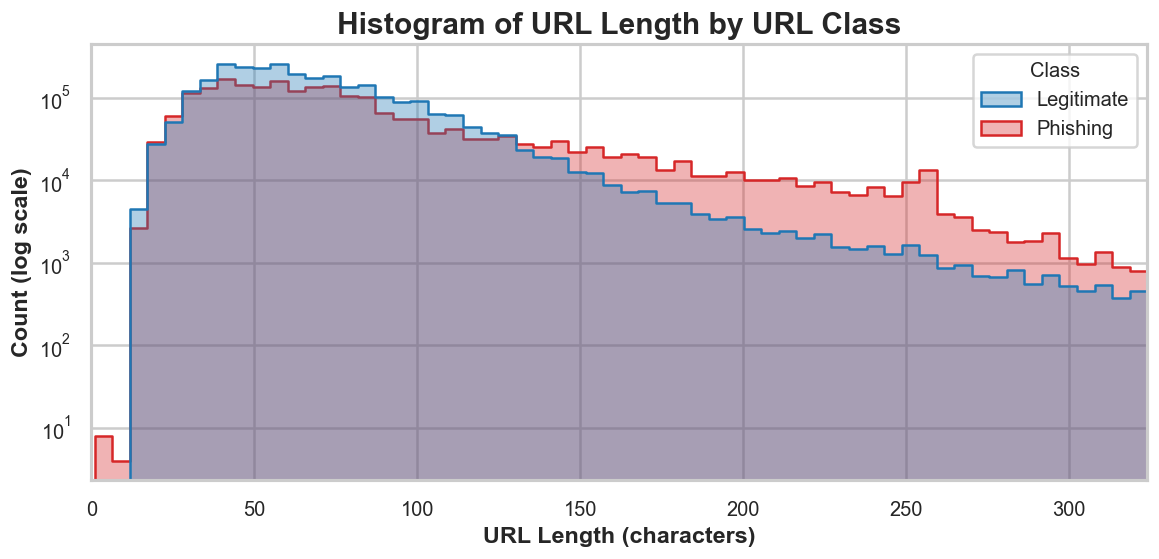

In [107]:
# Plot 1: URL length histogram
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(
    data=url_length_plot,
    x="URLLength",
    hue="Class",
    hue_order=CLASS_ORDER,
    palette=CLASS_PALETTE,
    bins=60,
    alpha=0.35,
    common_norm=False,
    stat="count",
    multiple="layer",
    element="step",
    ax=ax,
)
ax.set_yscale("log")
ax.set_xlim(0, url_length_cap)
ax.set_title("Histogram of URL Length by URL Class")
ax.set_xlabel("URL Length (characters)")
ax.set_ylabel("Count (log scale)")
legend = ax.get_legend()
if legend is not None:
    legend.set_title("Class")
plt.tight_layout()
plt.show()

### 5.3 Domain length distribution


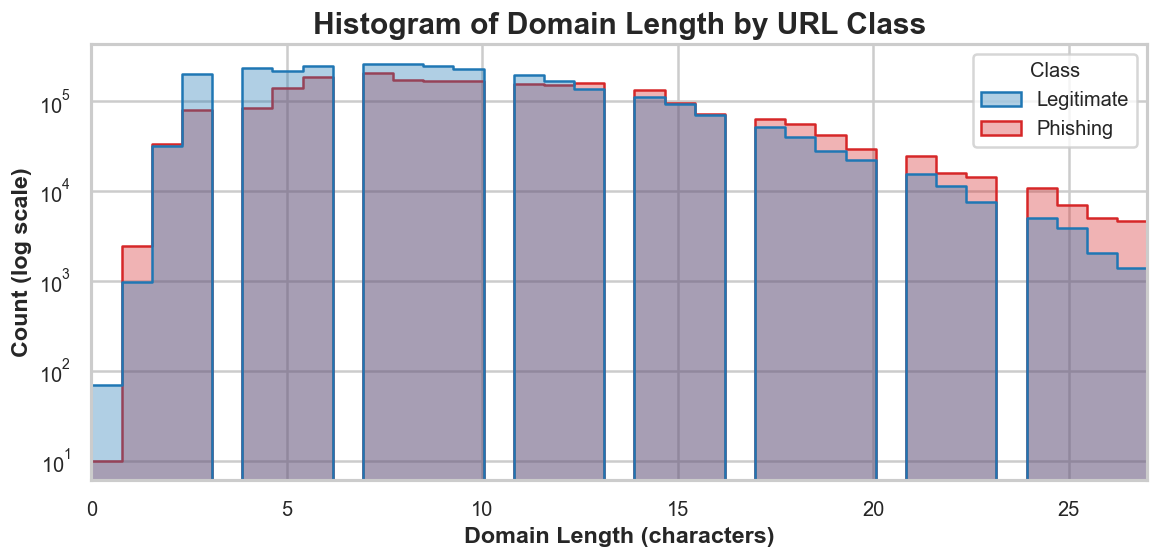

In [108]:
# Plot 2: Domain length histogram
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(
    data=domain_length_plot,
    x="DomainLength",
    hue="Class",
    hue_order=CLASS_ORDER,
    palette=CLASS_PALETTE,
    bins=35,
    alpha=0.35,
    common_norm=False,
    stat="count",
    multiple="layer",
    element="step",
    ax=ax,
)
ax.set_yscale("log")
ax.set_xlim(0, domain_length_cap)
ax.set_title("Histogram of Domain Length by URL Class")
ax.set_xlabel("Domain Length (characters)")
ax.set_ylabel("Count (log scale)")
legend = ax.get_legend()
if legend is not None:
    legend.set_title("Class")
plt.tight_layout()
plt.show()

### 5.4 Top 15 TLD frequencies


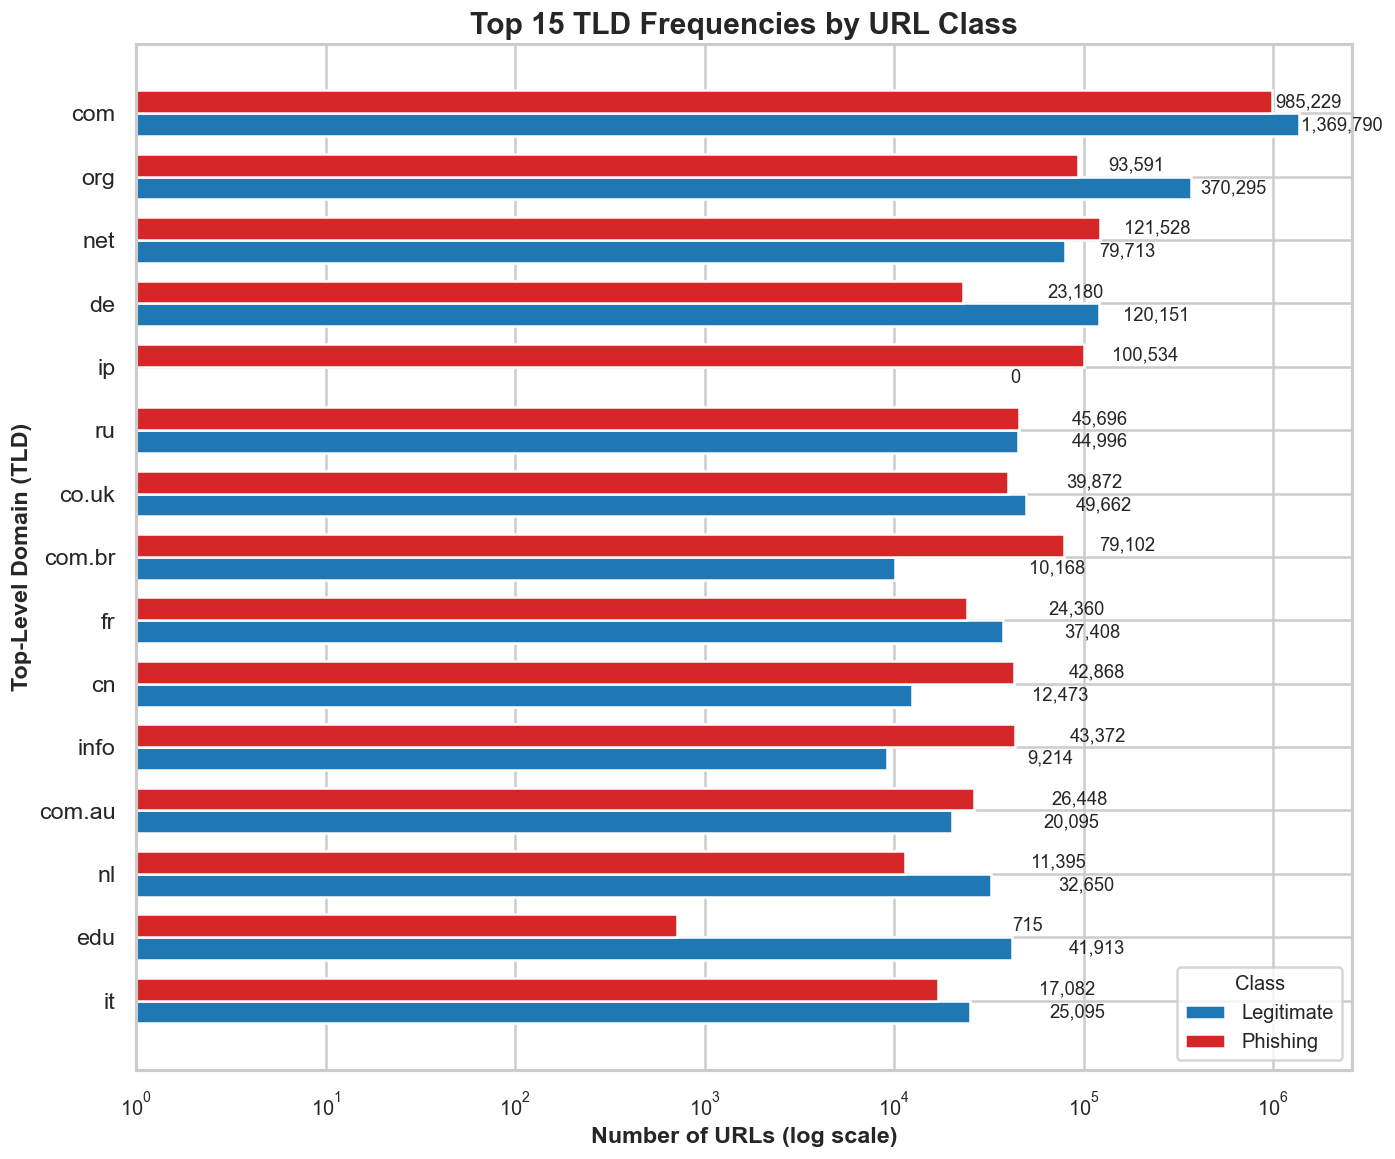

In [109]:
# Plot 3: Top 15 TLD grouped horizontal bars
tld_counts = (
    plot_df.groupby(["tld", "Class"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=CLASS_ORDER, fill_value=0)
)

top_tlds = tld_counts.sum(axis=1).sort_values(ascending=False).head(15).index
tld_counts = tld_counts.loc[top_tlds]
tld_counts["Total"] = tld_counts.sum(axis=1)
tld_counts = tld_counts.sort_values("Total", ascending=True).drop(columns="Total")

y_pos = np.arange(len(tld_counts.index))
bar_height = 0.36
max_tld_value = max(1, int(tld_counts.to_numpy().max()))
text_offset = max_tld_value * 0.03

fig, ax = plt.subplots(figsize=(12, 10))
ax.barh(y_pos - bar_height / 2, tld_counts["Legitimate"], height=bar_height, color=CLASS_PALETTE["Legitimate"], label="Legitimate")
ax.barh(y_pos + bar_height / 2, tld_counts["Phishing"], height=bar_height, color=CLASS_PALETTE["Phishing"], label="Phishing")

for idx, value in enumerate(tld_counts["Legitimate"]):
    ax.text(max(value, 1) + text_offset, idx - bar_height / 2, f"{value:,.0f}", va="center", ha="left", fontsize=11)
for idx, value in enumerate(tld_counts["Phishing"]):
    ax.text(max(value, 1) + text_offset, idx + bar_height / 2, f"{value:,.0f}", va="center", ha="left", fontsize=11)

ax.set_xscale("log")
ax.set_xlim(1, max_tld_value * 1.9)
ax.set_yticks(y_pos)
ax.set_yticklabels(tld_counts.index, fontsize=14)
ax.set_title("Top 15 TLD Frequencies by URL Class")
ax.set_xlabel("Number of URLs (log scale)")
ax.set_ylabel("Top-Level Domain (TLD)")
ax.legend(title="Class", loc="lower right")
plt.tight_layout()
plt.show()

### 5.5 Subdomain count by class


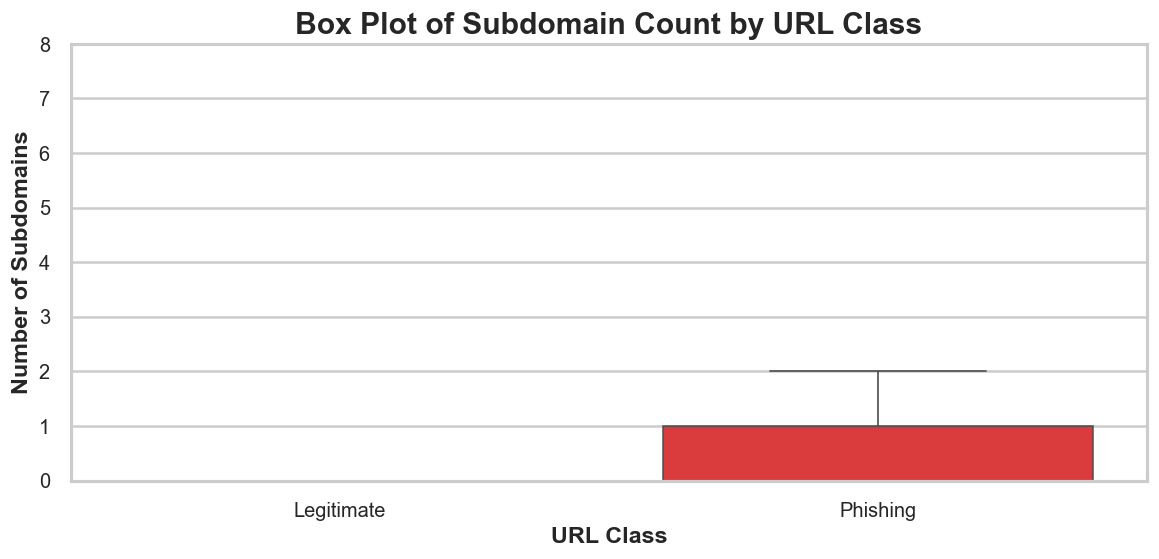

In [110]:
# Plot 4: Subdomain count box plot
fig, ax = plt.subplots(figsize=(10, 5))
box = sns.boxplot(
    data=subdomain_plot,
    x="Class",
    y="NoOfSubDomain",
    order=CLASS_ORDER,
    showfliers=False,
    ax=ax,
)

# Apply consistent class colors without requiring hue
for patch, class_name in zip(box.patches, CLASS_ORDER):
    patch.set_facecolor(CLASS_PALETTE[class_name])
    patch.set_alpha(0.9)

ax.set_ylim(0, subdomain_cap)
ax.set_title("Box Plot of Subdomain Count by URL Class")
ax.set_xlabel("URL Class")
ax.set_ylabel("Number of Subdomains")
plt.tight_layout()
plt.show()

### 5.5b Subdomain count distribution (discrete bins)


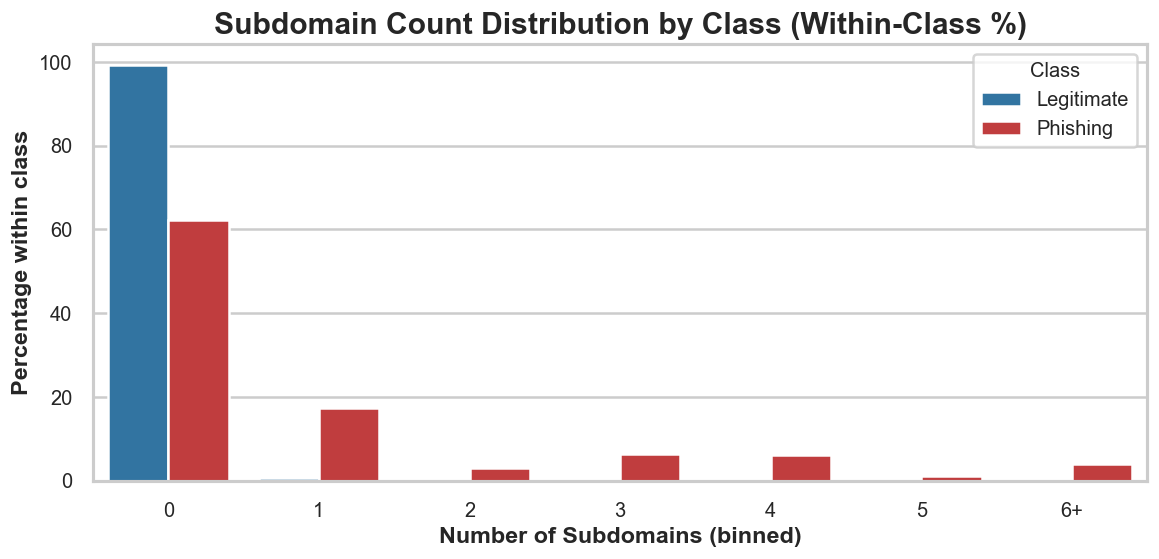

In [117]:
# Plot 4b: Discrete subdomain-count distribution by class
subdomain_dist = plot_df[["Class", "NoOfSubDomain"]].copy()
subdomain_dist["SubdomainBin"] = subdomain_dist["NoOfSubDomain"].clip(upper=6)
subdomain_dist["SubdomainBin"] = subdomain_dist["SubdomainBin"].astype(int).astype(str)
subdomain_dist.loc[subdomain_dist["NoOfSubDomain"] >= 6, "SubdomainBin"] = "6+"

bin_order = ["0", "1", "2", "3", "4", "5", "6+"]

subdomain_pct = (
    subdomain_dist.groupby(["Class", "SubdomainBin"], as_index=False)
    .size()
    .rename(columns={"size": "Count"})
)
subdomain_pct["Pct"] = (
    subdomain_pct["Count"]
    / subdomain_pct.groupby("Class")["Count"].transform("sum")
    * 100
)

subdomain_pct["SubdomainBin"] = pd.Categorical(
    subdomain_pct["SubdomainBin"],
    categories=bin_order,
    ordered=True,
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(
    data=subdomain_pct,
    x="SubdomainBin",
    y="Pct",
    hue="Class",
    hue_order=CLASS_ORDER,
    palette=CLASS_PALETTE,
    ax=ax,
)

ax.set_title("Subdomain Count Distribution by Class (Within-Class %)")
ax.set_xlabel("Number of Subdomains (binned)")
ax.set_ylabel("Percentage within class")
ax.legend(title="Class")
plt.tight_layout()
plt.show()

### 5.6 HTTPS usage by class


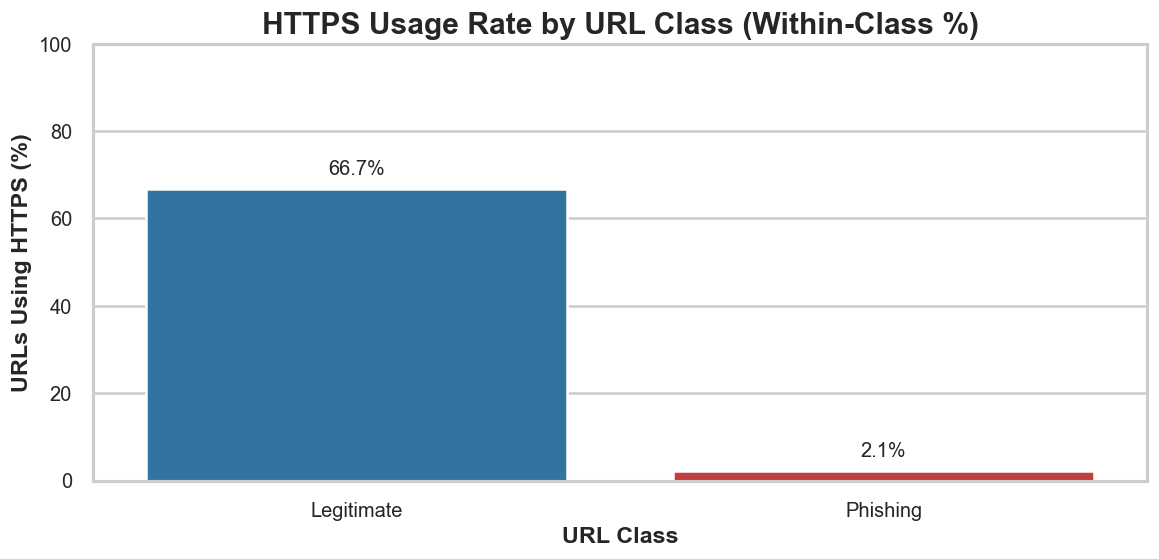

Overall HTTPS share of dataset: 38.03%


,Class,HTTPSShareOfDataset
0,Legitimate,37.080927
1,Phishing,0.952972


In [111]:
# Plot 5: HTTPS usage by class (within-class rate)
https_pct = (
    plot_df.groupby("Class")["IsHTTPS"]
    .mean()
    .mul(100)
    .reindex(CLASS_ORDER)
    .reset_index(name="HTTPSUsagePct")
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(
    data=https_pct,
    x="Class",
    y="HTTPSUsagePct",
    hue="Class",
    order=CLASS_ORDER,
    hue_order=CLASS_ORDER,
    palette=CLASS_PALETTE,
    dodge=False,
    legend=False,
    ax=ax,
)

for patch, value in zip(ax.patches, https_pct["HTTPSUsagePct"]):
    ax.annotate(
        f"{value:.1f}%",
        (patch.get_x() + patch.get_width() / 2, patch.get_height()),
        ha="center",
        va="bottom",
        fontsize=12,
        xytext=(0, 6),
        textcoords="offset points",
    )

ax.set_ylim(0, 100)
ax.set_title("HTTPS Usage Rate by URL Class (Within-Class %)")
ax.set_xlabel("URL Class")
ax.set_ylabel("URLs Using HTTPS (%)")
plt.tight_layout()
plt.show()

# Complementary view: share of the full dataset (sums to overall HTTPS%)
https_share_total = pd.DataFrame({
    "Class": CLASS_ORDER,
    "HTTPSShareOfDataset": [
        ((plot_df["Class"] == "Legitimate") & (plot_df["IsHTTPS"] == 1)).mean() * 100,
        ((plot_df["Class"] == "Phishing") & (plot_df["IsHTTPS"] == 1)).mean() * 100,
    ],
})

overall_https = plot_df["IsHTTPS"].mean() * 100
print(f"Overall HTTPS share of dataset: {overall_https:.2f}%")
display(https_share_total)

### 5.7 Letter-ratio distribution


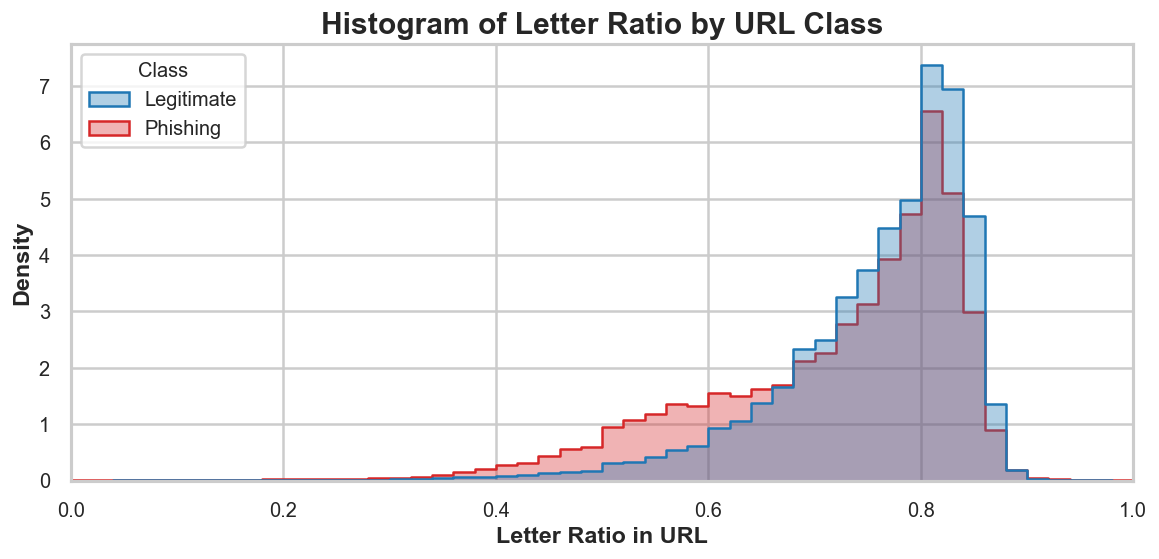

In [112]:
# Plot 6: Letter ratio histogram
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(
    data=plot_df,
    x="LetterRatioInURL",
    hue="Class",
    hue_order=CLASS_ORDER,
    palette=CLASS_PALETTE,
    bins=50,
    alpha=0.35,
    common_norm=False,
    stat="density",
    multiple="layer",
    element="step",
    ax=ax,
)
ax.set_xlim(0, 1)
ax.set_title("Histogram of Letter Ratio by URL Class")
ax.set_xlabel("Letter Ratio in URL")
ax.set_ylabel("Density")
legend = ax.get_legend()
if legend is not None:
    legend.set_title("Class")
plt.tight_layout()
plt.show()

### Observations from Visual EDA

1. **URL Length Distribution**  
   Observation: Phishing URLs often appear shifted toward longer lengths than legitimate URLs.

2. **Domain Length Distribution**  
   Observation: Domain length patterns differ by class, suggesting naming strategy differences.

3. **Top 15 TLD Frequency**  
   Observation: Some TLDs are disproportionately represented in one class, indicating potential risk signals.

4. **Subdomain Count Distribution**  
   Observation: Phishing URLs can show higher subdomain counts and more extreme outliers.

5. **HTTPS Usage**  
   Observation: HTTPS is not exclusive to legitimate URLs; phishing URLs can also use HTTPS.

6. **Letter Ratio Distribution**  
   Observation: Letter composition differs across classes, reflecting differences in URL construction style.


## SECTION 6 — Hypothesis from EDA

### Observation → Hypothesis

- **Observation:** Phishing URLs tend to be longer.  
  **Hypothesis:** `URLLength` may carry predictive signal.

- **Observation:** Domain length differs between classes.  
  **Hypothesis:** `DomainLength` may help separate suspicious domains.

- **Observation:** Certain TLDs are overrepresented in one class.  
  **Hypothesis:** `TLD` and `TLDLength` may be informative.

- **Observation:** Phishing URLs may include deeper subdomain chains.  
  **Hypothesis:** `NoOfSubDomain` can capture obfuscation patterns.

- **Observation:** URL character composition differs by class.  
  **Hypothesis:** `NoOfLettersInURL` and `LetterRatioInURL` can represent lexical structure.

- **Observation:** HTTPS appears in both classes.  
  **Hypothesis:** `IsHTTPS` should be included, but not treated as a standalone trust signal.


## SECTION 7 — Feature Engineering

Create the final engineered features derived from EDA insights.


### 7.1 Build engineered feature table


In [113]:
# Build engineered feature dataframe
features_df = df.copy()

parts = features_df["url"].apply(extract_parts)
features_df[["_subdomain", "Domain", "TLD"]] = pd.DataFrame(parts.tolist(), index=features_df.index)

features_df["URLLength"] = features_df["url"].str.len()
features_df["DomainLength"] = features_df["Domain"].str.len()
features_df["TLDLength"] = features_df["TLD"].str.len()
features_df["NoOfSubDomain"] = features_df["_subdomain"].apply(count_subdomains)
features_df["NoOfLettersInURL"] = features_df["url"].apply(count_letters)
features_df["LetterRatioInURL"] = np.where(
    features_df["URLLength"] > 0,
    features_df["NoOfLettersInURL"] / features_df["URLLength"],
    0.0,
)
features_df["IsHTTPS"] = features_df["url"].str.lower().str.startswith("https").astype(int)

final_columns = [
    "url", "URLLength", "Domain", "DomainLength", "TLD", "TLDLength",
    "NoOfSubDomain", "NoOfLettersInURL", "LetterRatioInURL", "IsHTTPS", "label",
]
final_df = features_df[final_columns].copy()

print(f"Engineered dataframe ready: {len(final_df):,} rows")

Engineered dataframe ready: 5,183,050 rows


### 7.2 Save engineered dataset to CSV


In [114]:
# Save engineered dataset
output_csv_path = "phishing_url_features.csv"
final_df.to_csv(output_csv_path, index=False)

print(f"Saved engineered dataset to: {output_csv_path}")
print(f"Rows: {len(final_df):,} | Columns: {len(final_df.columns)}")

Saved engineered dataset to: phishing_url_features.csv
Rows: 5,183,050 | Columns: 11


## SECTION 8 — Final Dataset Preview

Preview the final dataset with engineered features and provide a column description.


In [115]:
display(final_df.head())

print("\nColumn summary:")
column_description = pd.DataFrame(
    {
        "Column": final_df.columns,
        "Description": [
            "Original URL string",
            "Length of full URL",
            "Extracted second-level domain",
            "Length of domain string",
            "Extracted top-level domain (suffix)",
            "Length of TLD string",
            "Number of subdomains",
            "Count of alphabetic characters in URL",
            "Alphabetic character ratio in URL",
            "1 if URL uses HTTPS, else 0",
            "Target label (1=phishing, 0=legitimate)",
        ],
    }
)

display(column_description)

,url,URLLength,Domain,DomainLength,TLD,TLDLength,NoOfSubDomain,NoOfLettersInURL,LetterRatioInURL,IsHTTPS,label
0,https://blockchaoin.info/#/,27,blockchaoin,11,info,4,0,20,0.740741,1,1
1,https://www.insects.org/ced4/crush_freaks.html,46,insects,7,org,3,0,36,0.782609,1,0
2,https://www.elpasotimes.com/story/opinion/editorials/2015/11/17/editorial-terror-attack-brings-tough-choices/75960544/,118,elpasotimes,11,com,3,0,83,0.703390,1,0
3,http://direct-certs.bankofamerica.com.techdbaseurl46.cn/direct/certpickup.asp?session=52058170506675676020665110252458964995749207020054...,147,techdbaseurl46,14,cn,2,3,71,0.482993,0,1
4,https://gotham-magazine.com/lalique-unveils-epis-ring,53,gotham-magazine,15,com,3,0,44,0.830189,1,0



Column summary:


,Column,Description
0,url,Original URL string
1,URLLength,Length of full URL
2,Domain,Extracted second-level domain
3,DomainLength,Length of domain string
4,TLD,Extracted top-level domain (suffix)
5,TLDLength,Length of TLD string
6,NoOfSubDomain,Number of subdomains
7,NoOfLettersInURL,Count of alphabetic characters in URL
8,LetterRatioInURL,Alphabetic character ratio in URL
9,IsHTTPS,"1 if URL uses HTTPS, else 0"
